In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import healpy as hp
import pandas as pd

import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
import time

In [2]:
# Baseline Survey
baseline_file = "comp_survey_v5.2.0_10yrs.db" #get_baseline()
runName = os.path.split(baseline_file)[-1].replace('.db', '')


In [3]:
# Set up output
outDir = 'sn'
resultsDb = maf.db.ResultsDb(out_dir=outDir)


In [4]:
plotDict = {'percentileClip': 95., 'nTicks': 5}

sne_nside = 16
sn_summary = [maf.MedianMetric(), maf.MeanMetric(),
              maf.SumMetric(metric_name='Total detected')]
slicer = maf.HealpixSlicer(nside=sne_nside, use_cache=False)
#slicer = maf.HealpixSubsetSlicer(nside=16, hpid=[890], useCache=False)
#slicer = maf.HealpixSubsetSlicer(nside=16, hpid=[889], useCache=False)

metric = maf.SNNSNMetric(verbose=False)  
bundle = maf.MetricBundle(metric, slicer, "scheduler_note not like '%DD%' and night <= 365", plot_dict=plotDict,  
                        summary_metrics=sn_summary)

bg = maf.MetricBundleGroup({'sn': bundle}, baseline_file, outDir, resultsDb)


Healpix slicer using NSIDE=16, approximate resolution 219.871130 arcminutes
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 63121 799 79
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_-2.0_0.2_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 73508 799 92
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 g 20774 799 26


/Users/yoachim/anaconda3/envs/rubin_14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 i 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 r 50337 799 63
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 y 78302 799 98
Loading  /Users/yoachim/rubin_sim_data/maf/SNe_data/LC_0.0_0.0_380.0_800.0_ebvofMW_0.0_vstack.hdf5 z 88689 799 111


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/maps/dust_map.py:46: UserWarning: Slicer value of nside 16 different from map value 128, using slicer value
  warnings.warn(
/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/plots/plot_handler.py:665: UserWarning: Cannot plot object metric values with this plotter.
  warnings.warn("Cannot plot object metric values with this plotter.")


runtime= 376.7288236618042 s


/Users/yoachim/git_repos/rubin_sim/rubin_sim/maf/utils/maf_utils.py:153: UserWarning: Optimal bin calculation tried to make 206 bins, returning 200
  warnings.warn(


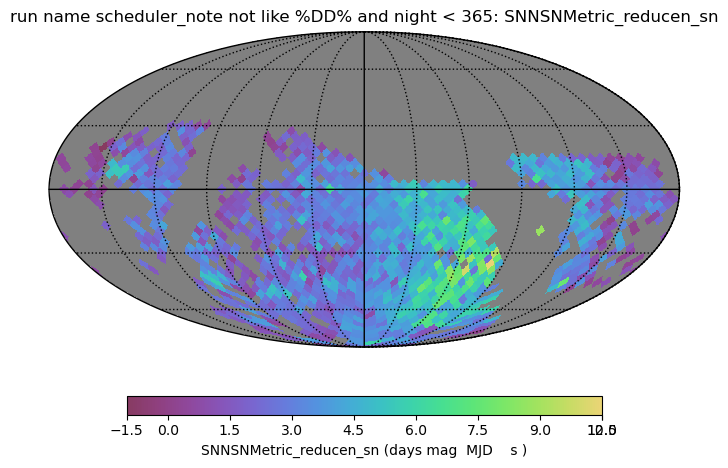

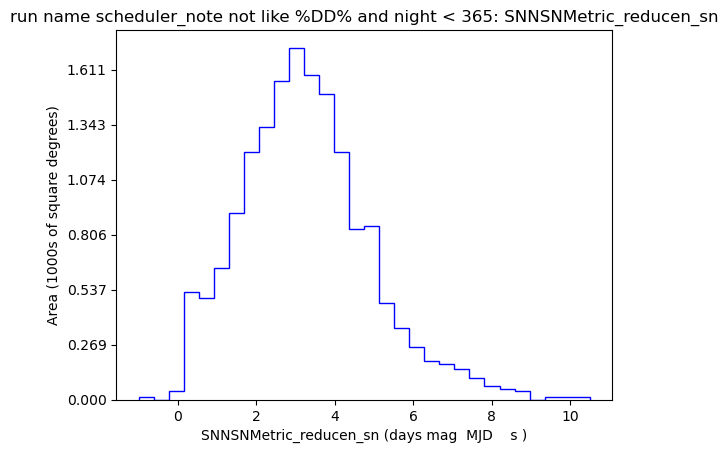

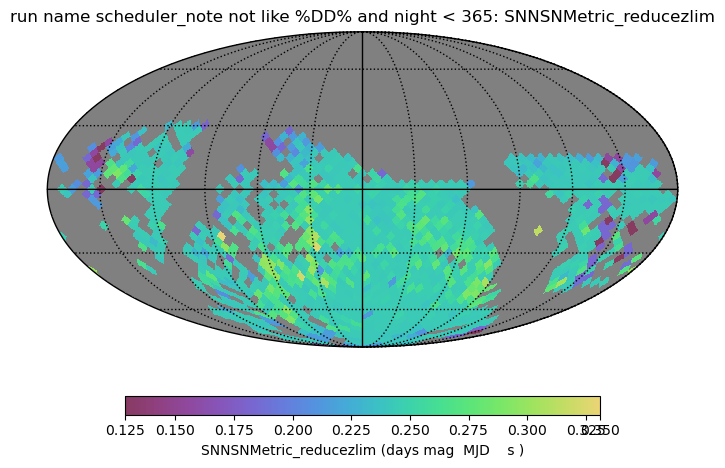

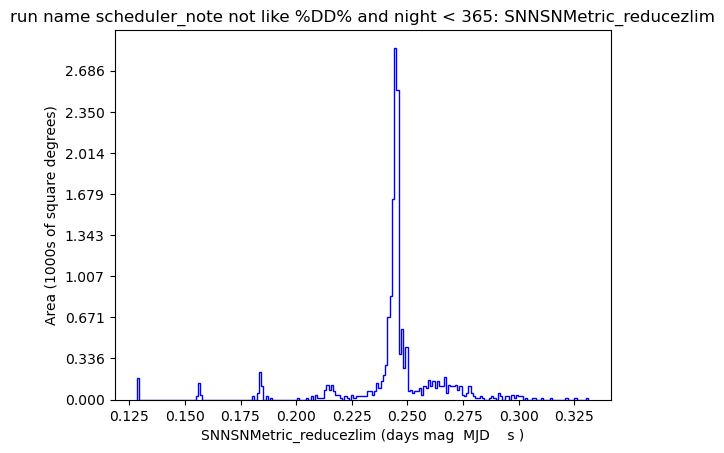

In [5]:
t1 = time.time()
bg.run_all()     
t2 = time.time()
bg.plot_all(closefigs=False)
print('runtime=', t2-t1, 's')


In [6]:
bg.bundle_dict["SNNSNMetric_reducen_sn"].metric_values.sum()

np.float64(3970.7951)

In [7]:
bg.bundle_dict["SNNSNMetric_reducezlim"].metric_values.mean()

np.float64(0.24371068327841847)